## Part 1: Helping functions and data loading

In [41]:
# Do not modify this cell, this is only for ploting the clusters
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")

    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.show()

In [42]:
# loading data
import numpy as np
X = np.load("part1_data.npz")["X"]

## K-means experiments

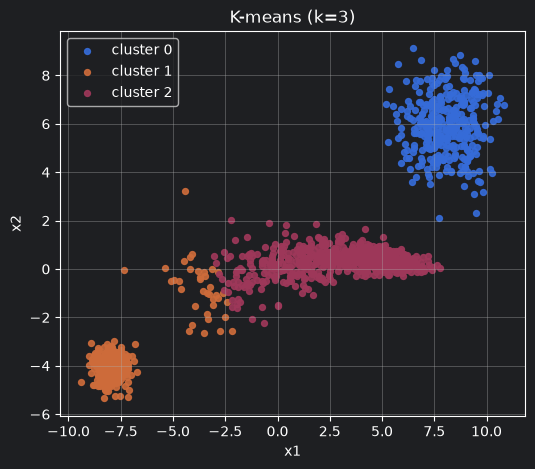

In [43]:
from sklearn.cluster import KMeans

# Number of clusters
K = 3

# Fit K-means and get labels
km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
labels = km.labels_

# ploting data
plot_clustering_result(X, labels, title=f"K-means (k={K})")

### K-Means Evaluation
Run the third cell below (i.e. the one that says evaluator = KMeansEvaluator(X))

Do this to evaluate K-means for different values of K. The code will compute the WCSS (inertia) and silhouette scores for K in the range 2 to 10, and plot the results. It will also print the best K based on the silhouette score.

In [44]:
from sklearn.metrics import silhouette_score

In [45]:
class KMeansEvaluator:
    def __init__(self, X, k_min=2, k_max=10, random_state=42):
        self.X = X
        self.k_range = range(k_min, k_max + 1)
        self.random_state = random_state
        self.wcss = []
        self.silhouette_scores = []

    def evaluate_wcss(self):
        """Fit K-means for each K and record inertia (WCSS)."""
        self.wcss = []
        for k in self.k_range:
            km = KMeans(n_clusters=k, random_state=self.random_state, n_init="auto").fit(self.X)
            self.wcss.append(km.inertia_)
        return self.wcss

    def evaluate_silhouette(self):
        """Fit K-means for each K and record the silhouette score."""
        self.silhouette_scores = []
        for k in self.k_range:
            km = KMeans(n_clusters=k, random_state=self.random_state, n_init="auto").fit(self.X)
            self.silhouette_scores.append(silhouette_score(self.X, km.labels_))
        return self.silhouette_scores

    def best_k(self):
        """Return the K with the highest silhouette score."""
        best_index = int(np.argmax(self.silhouette_scores))
        return list(self.k_range)[best_index]

    def plot(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(list(self.k_range), self.wcss, marker="o")
        axes[0].set_xlabel("K")
        axes[0].set_ylabel("WCSS (inertia)")
        axes[0].set_title("Elbow Method")
        axes[0].grid(True)

        axes[1].plot(list(self.k_range), self.silhouette_scores, marker="o")
        axes[1].set_xlabel("K")
        axes[1].set_ylabel("Silhouette Score")
        axes[1].set_title("Silhouette Score vs K")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    def main(self):
        self.evaluate_wcss()
        self.evaluate_silhouette()
        print(f"Best K by silhouette score: {self.best_k()} (score={max(self.silhouette_scores):.4f})")
        self.plot()

Best K by silhouette score: 3 (score=0.6966)


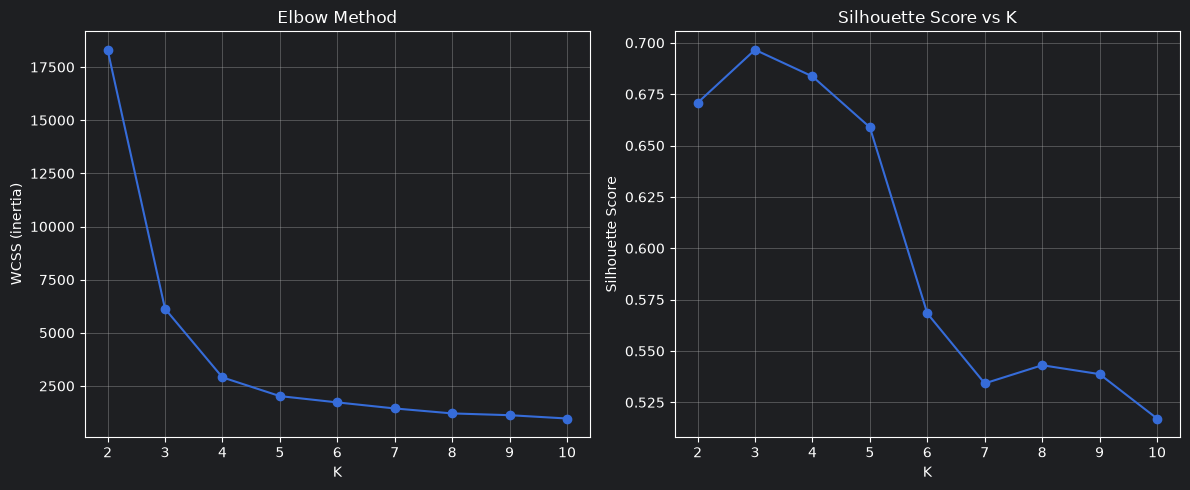

In [46]:
# Run the evaluator
evaluator = KMeansEvaluator(X)
evaluator.main()

### K-Means Discussion

**K = 3 was selected** because it produces the highest silhouette score (0.6966) among all tested values, and the WCSS/elbow curve shows only marginal reductions in inertia beyond this point, indicating diminishing returns from adding further clusters.

Visually, two of the three groups (the compact cluster in the top-right and the compact cluster in the bottom-left) are well separated and closely match what appear to be the salient groups in the data.

However, the third cluster is not cleanly separated: it forms an elongated, diagonal spread of points that blends with the bottom-left cluster near the region around x1 ≈ -5 to -2, where points from the two groups are visually intermixed rather than forming a clear boundary.

This blending occurs because K-means assumes roughly spherical, equally-sized clusters, so it struggles to correctly partition a non-convex, elongated distribution, instead splitting or merging points along that boundary based on distance to centroids rather than the true underlying structure.

Overall, K = 3 is a reasonable quantitative choice, but the elongated cluster suggests K-means' assumptions don't fully align with the true shape of at least one of the groups.

## DBSCAN experiments

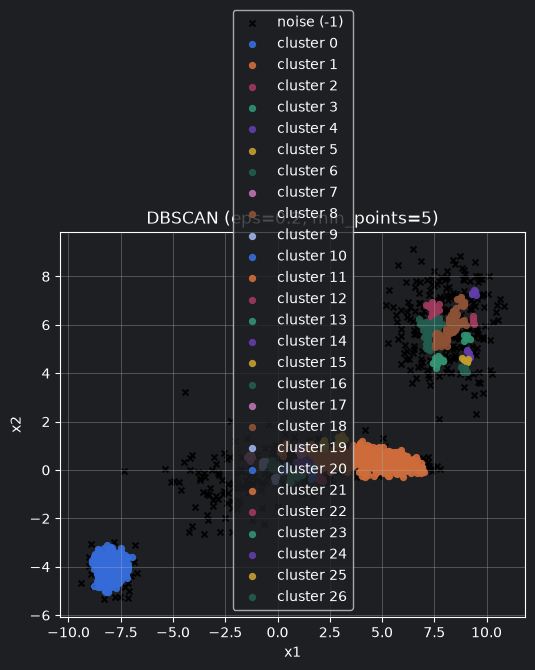

In [47]:
import numpy as np
from sklearn.cluster import DBSCAN

# Vary these
EPS = 0.2          # epsilon=neighbourhood radius
MIN_POINTS = 5     # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, title=f"DBSCAN (eps={EPS}, min_points={MIN_POINTS})")

DBSCAN Discussion